In [19]:
print("SARIMA columns:")
print(sarima.columns.tolist())

print("\nFirst 10 SARIMA rows:")
display(sarima.head(10))

print("\nLast 10 SARIMA rows:")
display(sarima.tail(10))

print("\nSARIMA data types:")
print(sarima.dtypes)

SARIMA columns:
['month', '0']

First 10 SARIMA rows:


,month,0
0,2022-02-01,-0.788963
1,2022-03-01,0.546056
2,2022-04-01,0.758928
3,2022-05-01,1.248349
4,2022-06-01,-0.410554
5,2022-07-01,-0.526320
6,2022-08-01,-0.438537
7,2022-09-01,-0.154996
8,2022-10-01,-0.291103
9,2022-11-01,-0.277026



Last 10 SARIMA rows:


,month,0
37,2025-03-01,0.954567
38,2025-04-01,-0.284852
39,2025-05-01,-0.245585
40,2025-06-01,-0.628805
41,2025-07-01,0.636877
42,2025-08-01,0.141679
43,2025-09-01,-1.133886
44,2025-10-01,-1.612101
45,2025-11-01,0.662010
46,2025-12-01,0.298262



SARIMA data types:
month    datetime64[ns]
0               float64
dtype: object


In [20]:
sarima_monthly = (
    sarima[
        ["month", "0"]
    ]
    .rename(columns={"0": "sarima_resid_z"})
    .drop_duplicates(subset=["month"])
    .sort_values("month")
    .reset_index(drop=True)
)

print("SARIMA monthly table:")
print("Rows:", len(sarima_monthly))
print("Date range:",
      sarima_monthly["month"].min(),
      "to",
      sarima_monthly["month"].max())

print("\nDuplicate months:",
      sarima_monthly["month"].duplicated().sum())

display(sarima_monthly.head())
display(sarima_monthly.tail())

SARIMA monthly table:
Rows: 47
Date range: 2022-02-01 00:00:00 to 2025-12-01 00:00:00

Duplicate months: 0


,month,sarima_resid_z
0,2022-02-01,-0.788963
1,2022-03-01,0.546056
2,2022-04-01,0.758928
3,2022-05-01,1.248349
4,2022-06-01,-0.410554


,month,sarima_resid_z
42,2025-08-01,0.141679
43,2025-09-01,-1.133886
44,2025-10-01,-1.612101
45,2025-11-01,0.662010
46,2025-12-01,0.298262


In [21]:
# ============================================================
# STEP 3 — MERGE AUTHORITATIVE ISS + SARIMA
# ============================================================

iss_sarima = (
    iss_monthly
    .merge(
        sarima_monthly,
        on="month",
        how="inner"
    )
    .sort_values("month")
    .reset_index(drop=True)
)

print("=" * 70)
print("ISS + SARIMA MERGE")
print("=" * 70)

print("Rows:", len(iss_sarima))
print("First month:", iss_sarima["month"].min())
print("Last month:", iss_sarima["month"].max())

print("\nDuplicate months:",
      iss_sarima["month"].duplicated().sum())

print("\nColumns:")
print(iss_sarima.columns.tolist())

print("\nAll overlapping months:")
print(
    iss_sarima["month"]
    .dt.strftime("%Y-%m")
    .tolist()
)

print("\nMissing values:")
print(iss_sarima.isna().sum())

display(iss_sarima.head())
display(iss_sarima.tail())

ISS + SARIMA MERGE
Rows: 24
First month: 2024-01-01 00:00:00
Last month: 2025-12-01 00:00:00

Duplicate months: 0

Columns:
['month', 'iss_mean_z', 'iss_max_z', 'sarima_resid_z']

All overlapping months:
['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']

Missing values:
month             0
iss_mean_z        0
iss_max_z         0
sarima_resid_z    0
dtype: int64


,month,iss_mean_z,iss_max_z,sarima_resid_z
0,2024-01-01,0.165913,1.330143,0.053174
1,2024-02-01,1.334491,2.376912,0.556438
2,2024-03-01,0.628053,1.823902,0.606408
3,2024-04-01,2.889914,3.379372,-0.686701
4,2024-05-01,0.397366,1.738498,-0.170401


,month,iss_mean_z,iss_max_z,sarima_resid_z
19,2025-08-01,-0.413472,0.540129,0.141679
20,2025-09-01,-0.472791,0.654884,-1.133886
21,2025-10-01,-0.500404,0.213487,-1.612101
22,2025-11-01,-0.624556,-0.198155,0.662010
23,2025-12-01,0.101110,0.911511,0.298262


In [22]:
# ============================================================
# STEP 4 — INSPECT REAL M/M/1 CAPACITY DATA
# ============================================================

print("=" * 70)
print("M/M/1 QUEUING RESULTS CHECK")
print("=" * 70)

print("Shape:", mm1.shape)

print("\nColumns:")
print(mm1.columns.tolist())

print("\nData types:")
print(mm1.dtypes)

print("\nFirst 10 rows:")
display(mm1.head(10))

print("\nLast 10 rows:")
display(mm1.tail(10))

M/M/1 QUEUING RESULTS CHECK
Shape: (66, 11)

Columns:
['month', 'volume_mn', 'value_cr', 'days_in_month', 'seconds_in_month', 'total_transactions', 'lambda_avg_tps', 'rho_floor', 'rho_sens_low', 'rho_sens_high', 'rho_peak_baseline']

Data types:
month                 datetime64[ns]
volume_mn                    float64
value_cr                     float64
days_in_month                  int64
seconds_in_month               int64
total_transactions           float64
lambda_avg_tps               float64
rho_floor                    float64
rho_sens_low                 float64
rho_sens_high                float64
rho_peak_baseline            float64
dtype: object

First 10 rows:


,month,volume_mn,value_cr,days_in_month,seconds_in_month,total_transactions,lambda_avg_tps,rho_floor,rho_sens_low,rho_sens_high,rho_peak_baseline
0,2021-01-01,2302.73,431181.89,31,2678400,2.302730e+09,859.740890,0.124540,0.103783,0.069189,0.098100
1,2021-02-01,2292.90,425062.76,28,2419200,2.292900e+09,947.792659,0.137295,0.114413,0.076275,0.108147
2,2021-03-01,2731.68,504886.44,31,2678400,2.731680e+09,1019.892473,0.147739,0.123116,0.082077,0.116374
3,2021-04-01,2641.06,493663.68,30,2592000,2.641060e+09,1018.927469,0.147600,0.123000,0.082000,0.116264
4,2021-05-01,2539.57,490638.65,31,2678400,2.539570e+09,948.166816,0.137349,0.114458,0.076305,0.108190
5,2021-06-01,2807.51,547373.17,30,2592000,2.807510e+09,1083.144290,0.156902,0.130752,0.087168,0.123591
6,2021-07-01,3247.82,606281.14,31,2678400,3.247820e+09,1212.597073,0.175654,0.146378,0.097586,0.138362
7,2021-08-01,3555.55,639116.95,31,2678400,3.555550e+09,1327.490293,0.192297,0.160248,0.106832,0.151472
8,2021-09-01,3654.30,654351.81,30,2592000,3.654300e+09,1409.837963,0.204226,0.170188,0.113459,0.160868
9,2021-10-01,4218.65,771444.98,31,2678400,4.218650e+09,1575.063471,0.228160,0.190133,0.126756,0.179721



Last 10 rows:


,month,volume_mn,value_cr,days_in_month,seconds_in_month,total_transactions,lambda_avg_tps,rho_floor,rho_sens_low,rho_sens_high,rho_peak_baseline
56,2025-09-01,19633.43,2489736.54,30,2592000,1.963343e+10,7574.625772,1.097243,0.914369,0.609579,0.864297
57,2025-10-01,20700.92,2727790.68,31,2678400,2.070092e+10,7728.838112,1.119582,0.932985,0.621990,0.881893
58,2025-11-01,20466.98,2631632.63,30,2592000,2.046698e+10,7896.211420,1.143827,0.953189,0.635460,0.900991
59,2025-12-01,21634.67,2796712.73,31,2678400,2.163467e+10,8077.460424,1.170082,0.975069,0.650046,0.921673
60,2026-01-01,21703.44,2833481.22,31,2678400,2.170344e+10,8103.136201,1.173802,0.978168,0.652112,0.924602
61,2026-02-01,20394.18,2684229.29,28,2419200,2.039418e+10,8430.133929,1.221170,1.017642,0.678428,0.961914
62,2026-03-01,22641.11,2952542.05,31,2678400,2.264111e+10,8453.222073,1.224514,1.020429,0.680286,0.964549
63,2026-04-01,22346.80,2902988.05,30,2592000,2.234680e+10,8621.450617,1.248884,1.040736,0.693824,0.983744
64,2026-05-01,23201.93,2990424.21,31,2678400,2.320193e+10,8662.608274,1.254846,1.045705,0.697136,0.988440
65,2026-06-01,22716.07,2892138.67,30,2592000,2.271607e+10,8763.915895,1.269521,1.057934,0.705289,1.000000


In [23]:
# ============================================================
# STEP 5 — MERGE PRIMARY CAPACITY SIGNAL
# ============================================================

capacity_monthly = (
    mm1[
        ["month", "rho_peak_baseline"]
    ]
    .drop_duplicates(subset=["month"])
    .sort_values("month")
    .reset_index(drop=True)
)

ampi_base = (
    iss_sarima
    .merge(
        capacity_monthly,
        on="month",
        how="inner"
    )
    .sort_values("month")
    .reset_index(drop=True)
)

print("=" * 70)
print("FULL AMPI INPUT MERGE")
print("=" * 70)

print("Rows:", len(ampi_base))
print("First month:", ampi_base["month"].min())
print("Last month:", ampi_base["month"].max())

print("\nDuplicate months:",
      ampi_base["month"].duplicated().sum())

print("\nColumns:")
print(ampi_base.columns.tolist())

print("\nMissing values:")
print(ampi_base.isna().sum())

print("\nAMPI input data:")
display(ampi_base)

FULL AMPI INPUT MERGE
Rows: 24
First month: 2024-01-01 00:00:00
Last month: 2025-12-01 00:00:00

Duplicate months: 0

Columns:
['month', 'iss_mean_z', 'iss_max_z', 'sarima_resid_z', 'rho_peak_baseline']

Missing values:
month                0
iss_mean_z           0
iss_max_z            0
sarima_resid_z       0
rho_peak_baseline    0
dtype: int64

AMPI input data:


,month,iss_mean_z,iss_max_z,sarima_resid_z,rho_peak_baseline
0,2024-01-01,0.165913,1.330143,0.053174,0.519869
1,2024-02-01,1.334491,2.376912,0.556438,0.551152
2,2024-03-01,0.628053,1.823902,0.606408,0.572566
3,2024-04-01,2.889914,3.379372,-0.686701,0.585664
4,2024-05-01,0.397366,1.738498,-0.170401,0.597950
5,2024-06-01,-0.341698,0.277416,-0.300532,0.611247
6,2024-07-01,-0.260246,0.815506,-0.420980,0.614978
7,2024-08-01,0.581814,0.841145,-0.434719,0.637451
8,2024-09-01,-0.433303,-0.012881,-0.258480,0.662163
9,2024-10-01,-0.594233,-0.543342,1.481418,0.706547


In [24]:
# ============================================================
# STEP 6 — AMPI GOALPOST NORMALIZATION
# ============================================================

def ampi_normalize(series):
    xmin = series.min()
    xmax = series.max()

    if xmax == xmin:
        return pd.Series(100.0, index=series.index)

    return 70 + 60 * ((series - xmin) / (xmax - xmin))


ampi_base["iss_mean_norm"] = ampi_normalize(
    ampi_base["iss_mean_z"]
)

ampi_base["sarima_norm"] = ampi_normalize(
    ampi_base["sarima_resid_z"]
)

ampi_base["rho_norm"] = ampi_normalize(
    ampi_base["rho_peak_baseline"]
)

print("=" * 70)
print("AMPI GOALPOST NORMALIZATION")
print("=" * 70)

print("\nRaw indicator ranges:")
for col in [
    "iss_mean_z",
    "sarima_resid_z",
    "rho_peak_baseline"
]:
    print(
        f"{col}: "
        f"min = {ampi_base[col].min():.6f}, "
        f"max = {ampi_base[col].max():.6f}"
    )

print("\nNormalized indicator ranges:")
for col in [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm"
]:
    print(
        f"{col}: "
        f"min = {ampi_base[col].min():.4f}, "
        f"max = {ampi_base[col].max():.4f}"
    )

display(
    ampi_base[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm"
        ]
    ]
)

AMPI GOALPOST NORMALIZATION

Raw indicator ranges:
iss_mean_z: min = -0.624556, max = 2.889914
sarima_resid_z: min = -1.720084, max = 1.481418
rho_peak_baseline: min = 0.519869, max = 0.921673

Normalized indicator ranges:
iss_mean_norm: min = 70.0000, max = 130.0000
sarima_norm: min = 70.0000, max = 130.0000
rho_norm: min = 70.0000, max = 130.0000


,month,iss_mean_norm,sarima_norm,rho_norm
0,2024-01-01,83.495102,103.232987,70.000000
1,2024-02-01,103.445385,112.664763,74.671400
2,2024-03-01,91.384883,113.601252,77.869122
3,2024-04-01,130.000000,89.366849,79.825023
4,2024-05-01,87.446533,99.042926,81.659593
5,2024-06-01,74.829032,96.604115,83.645277
6,2024-07-01,76.219596,94.346764,84.202372
7,2024-08-01,90.595480,94.089288,87.558094
8,2024-09-01,73.265122,97.392210,91.248382
9,2024-10-01,70.517691,130.000000,97.876034


In [25]:
# ============================================================
# STEP 7 — GENERALIZED AMPI CALCULATION
# ============================================================

ampi_indicators = [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm"
]

# Arithmetic mean
ampi_base["Mean"] = ampi_base[ampi_indicators].mean(axis=1)

# Population standard deviation
ampi_base["Population_SD"] = ampi_base[ampi_indicators].std(
    axis=1,
    ddof=0
)

# Coefficient of variation
ampi_base["CV"] = (
    ampi_base["Population_SD"] /
    ampi_base["Mean"]
)

# Non-compensatory penalty
ampi_base["Penalty"] = (
    ampi_base["CV"] *
    ampi_base["Population_SD"]
)

# Final AMPI
ampi_base["AMPI_final"] = (
    ampi_base["Mean"] +
    ampi_base["Penalty"]
)

print("=" * 70)
print("AMPI CALCULATION — 24 MONTHS")
print("=" * 70)

print("\nObservations:", len(ampi_base))

print("\nAMPI statistics:")
print(f"Minimum : {ampi_base['AMPI_final'].min():.4f}")
print(f"Maximum : {ampi_base['AMPI_final'].max():.4f}")
print(f"Mean    : {ampi_base['AMPI_final'].mean():.4f}")
print(f"Median  : {ampi_base['AMPI_final'].median():.4f}")

print("\nFormula consistency check:")

max_difference = np.abs(
    ampi_base["AMPI_final"] -
    (ampi_base["Mean"] + ampi_base["Penalty"])
).max()

print(
    f"Maximum difference: {max_difference:.10f}"
)

print("\nFinal AMPI values:")

display(
    ampi_base[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "Mean",
            "Population_SD",
            "CV",
            "Penalty",
            "AMPI_final"
        ]
    ].round(4)
)

AMPI CALCULATION — 24 MONTHS

Observations: 24

AMPI statistics:
Minimum : 84.8391
Maximum : 110.2834
Mean    : 96.5921
Median  : 96.6916

Formula consistency check:
Maximum difference: 0.0000000000

Final AMPI values:


,month,iss_mean_norm,sarima_norm,rho_norm,Mean,Population_SD,CV,Penalty,AMPI_final
0,2024-01-01,83.4951,103.2330,70.0000,85.5760,13.6469,0.1595,2.1763,87.7523
1,2024-02-01,103.4454,112.6648,74.6714,96.9272,16.1810,0.1669,2.7013,99.6284
2,2024-03-01,91.3849,113.6013,77.8691,94.2851,14.7310,0.1562,2.3016,96.5866
3,2024-04-01,130.0000,89.3668,79.8250,99.7306,21.7553,0.2181,4.7457,104.4763
4,2024-05-01,87.4465,99.0429,81.6596,89.3830,7.2276,0.0809,0.5844,89.9675
5,2024-06-01,74.8290,96.6041,83.6453,85.0261,8.9431,0.1052,0.9406,85.9668
6,2024-07-01,76.2196,94.3468,84.2024,84.9229,7.4179,0.0873,0.6479,85.5709
7,2024-08-01,90.5955,94.0893,87.5581,90.7476,2.6685,0.0294,0.0785,90.8261
8,2024-09-01,73.2651,97.3922,91.2484,87.3019,10.2375,0.1173,1.2005,88.5024
9,2024-10-01,70.5177,130.0000,97.8760,99.4646,24.3095,0.2444,5.9413,105.4059


In [26]:
# ============================================================
# STEP 8 — FINAL 24-MONTH AMPI RANKING
# ============================================================

ampi_ranking = (
    ampi_base[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "Mean",
            "Population_SD",
            "CV",
            "Penalty",
            "AMPI_final"
        ]
    ]
    .sort_values(
        "AMPI_final",
        ascending=False
    )
    .reset_index(drop=True)
)

ampi_ranking.insert(
    0,
    "Rank",
    range(1, len(ampi_ranking) + 1)
)

print("=" * 75)
print("FINAL 24-MONTH AMPI RANKING")
print("=" * 75)

display(
    ampi_ranking.round(4)
)

print("\nTop AMPI month:")
print(
    ampi_ranking.loc[
        0,
        ["month", "AMPI_final"]
    ]
)

print("\nLowest AMPI month:")
print(
    ampi_ranking.loc[
        len(ampi_ranking) - 1,
        ["month", "AMPI_final"]
    ]
)

FINAL 24-MONTH AMPI RANKING


,Rank,month,iss_mean_norm,sarima_norm,rho_norm,Mean,Population_SD,CV,Penalty,AMPI_final
0,1,2025-12-01,82.3888,107.8262,130.0000,106.7383,19.4524,0.1822,3.5451,110.2834
1,2,2025-11-01,70.0000,114.6433,126.9117,103.8517,24.4551,0.2355,5.7587,109.6104
2,3,2025-07-01,81.1712,114.1723,116.2163,103.8533,16.0603,0.1546,2.4836,106.3369
3,4,2025-03-01,79.6518,120.1262,108.7959,102.8579,17.0487,0.1658,2.8258,105.6838
4,5,2024-10-01,70.5177,130.0000,97.8760,99.4646,24.3095,0.2444,5.9413,105.4059
5,6,2024-04-01,130.0000,89.3668,79.8250,99.7306,21.7553,0.2181,4.7457,104.4763
6,7,2025-08-01,73.6037,104.8917,119.6538,99.3831,19.1992,0.1932,3.7090,103.0920
7,8,2024-02-01,103.4454,112.6648,74.6714,96.9272,16.1810,0.1669,2.7013,99.6284
8,9,2025-01-01,87.9731,104.7037,100.4908,97.7225,7.1052,0.0727,0.5166,98.2391
9,10,2025-05-01,77.1734,97.6339,111.1875,95.3316,13.9813,0.1467,2.0505,97.3821



Top AMPI month:
month         2025-12-01 00:00:00
AMPI_final             110.283422
Name: 0, dtype: object

Lowest AMPI month:
month         2024-11-01 00:00:00
AMPI_final              84.839062
Name: 23, dtype: object


In [27]:
import os

print("=" * 70)
print("SEARCHING FOR SARIMA RESIDUAL FILE")
print("=" * 70)

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

SEARCHING FOR SARIMA RESIDUAL FILE
/content/UPI_Master_Dataset.csv
/content/mm1_queuing_results.csv
/content/mm1_final_results.csv
/content/sarima_residuals.csv
/content/sample_data/mnist_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv


In [28]:
import pandas as pd

UPI_PATH = "/content/UPI_Master_Dataset.csv"
SARIMA_PATH = "/content/sarima_residuals.csv"
MM1_PATH = "/content/mm1_queuing_results.csv"

upi = pd.read_csv(UPI_PATH)
sarima = pd.read_csv(SARIMA_PATH)
mm1 = pd.read_csv(MM1_PATH)

print("=" * 70)
print("AUTHORITATIVE AMPI INPUTS")
print("=" * 70)

print("\nUPI_Master_Dataset")
print("Shape:", upi.shape)
print("Columns:", list(upi.columns))

print("\nSARIMA residuals")
print("Shape:", sarima.shape)
print("Columns:", list(sarima.columns))
print(sarima.head())

print("\nM/M/1 queuing results")
print("Shape:", mm1.shape)
print("Columns:", list(mm1.columns))

AUTHORITATIVE AMPI INPUTS

UPI_Master_Dataset
Shape: (125, 8)
Columns: ['month', 'upi_remitter_banks', 'total_volume_in_mn', 'td_pct', 'iss_mean_z', 'iss_max_z', 'stress_flag', 'max_bank']

SARIMA residuals
Shape: (47, 2)
Columns: ['month', '0']
        month         0
0  2022-02-01 -0.788963
1  2022-03-01  0.546056
2  2022-04-01  0.758928
3  2022-05-01  1.248349
4  2022-06-01 -0.410554

M/M/1 queuing results
Shape: (66, 11)
Columns: ['month', 'volume_mn', 'value_cr', 'days_in_month', 'seconds_in_month', 'total_transactions', 'lambda_avg_tps', 'rho_floor', 'rho_sens_low', 'rho_sens_high', 'rho_peak_baseline']


In [29]:
# Convert month columns to datetime
upi["month"] = pd.to_datetime(upi["month"])
sarima["month"] = pd.to_datetime(sarima["month"])
mm1["month"] = pd.to_datetime(mm1["month"])

# Rename SARIMA residual column without changing its values
sarima = sarima.rename(columns={"0": "sarima_resid_z"})

print("=" * 70)
print("INPUT STANDARDIZATION")
print("=" * 70)

print("\nSARIMA columns:")
print(list(sarima.columns))

print("\nSARIMA date range:")
print(sarima["month"].min(), "to", sarima["month"].max())

print("\nSARIMA duplicate months:", sarima["month"].duplicated().sum())

print("\nUPI date range:")
print(upi["month"].min(), "to", upi["month"].max())

print("\nUPI duplicate rows:", upi.duplicated().sum())

print("\nM/M/1 date range:")
print(mm1["month"].min(), "to", mm1["month"].max())

print("\nM/M/1 duplicate months:", mm1["month"].duplicated().sum())

INPUT STANDARDIZATION

SARIMA columns:
['month', 'sarima_resid_z']

SARIMA date range:
2022-02-01 00:00:00 to 2025-12-01 00:00:00

SARIMA duplicate months: 0

UPI date range:
2024-01-01 00:00:00 to 2026-01-01 00:00:00

UPI duplicate rows: 0

M/M/1 date range:
2021-01-01 00:00:00 to 2026-06-01 00:00:00

M/M/1 duplicate months: 0


In [30]:
# Select the required ISS columns from the authoritative UPI master dataset
iss_monthly = (
    upi[
        ["month", "iss_mean_z", "iss_max_z"]
    ]
    .drop_duplicates(subset="month")
    .sort_values("month")
    .reset_index(drop=True)
)

# Select the required SARIMA signal
sarima_monthly = (
    sarima[
        ["month", "sarima_resid_z"]
    ]
    .sort_values("month")
    .reset_index(drop=True)
)

# Select the primary capacity signal from the verified M/M/1 results
capacity_monthly = (
    mm1[
        ["month", "rho_peak_baseline"]
    ]
    .sort_values("month")
    .reset_index(drop=True)
)

# Merge ISS + SARIMA
ampi_input = pd.merge(
    iss_monthly,
    sarima_monthly,
    on="month",
    how="inner"
)

# Add primary capacity signal
ampi_input = pd.merge(
    ampi_input,
    capacity_monthly,
    on="month",
    how="inner"
)

ampi_input = (
    ampi_input
    .sort_values("month")
    .reset_index(drop=True)
)

print("=" * 70)
print("FULL AMPI INPUT MERGE")
print("=" * 70)

print("Rows:", len(ampi_input))
print("First month:", ampi_input["month"].min())
print("Last month:", ampi_input["month"].max())

print("\nDuplicate months:", ampi_input["month"].duplicated().sum())

print("\nColumns:")
print(list(ampi_input.columns))

print("\nMissing values:")
print(ampi_input.isna().sum())

print("\nAMPI input data:")
display(ampi_input)

FULL AMPI INPUT MERGE
Rows: 24
First month: 2024-01-01 00:00:00
Last month: 2025-12-01 00:00:00

Duplicate months: 0

Columns:
['month', 'iss_mean_z', 'iss_max_z', 'sarima_resid_z', 'rho_peak_baseline']

Missing values:
month                0
iss_mean_z           0
iss_max_z            0
sarima_resid_z       0
rho_peak_baseline    0
dtype: int64

AMPI input data:


,month,iss_mean_z,iss_max_z,sarima_resid_z,rho_peak_baseline
0,2024-01-01,0.165913,1.330143,0.053174,0.519869
1,2024-02-01,1.334491,2.376912,0.556438,0.551152
2,2024-03-01,0.628053,1.823902,0.606408,0.572566
3,2024-04-01,2.889914,3.379372,-0.686701,0.585664
4,2024-05-01,0.397366,1.738498,-0.170401,0.597950
5,2024-06-01,-0.341698,0.277416,-0.300532,0.611247
6,2024-07-01,-0.260246,0.815506,-0.420980,0.614978
7,2024-08-01,0.581814,0.841145,-0.434719,0.637451
8,2024-09-01,-0.433303,-0.012881,-0.258480,0.662163
9,2024-10-01,-0.594233,-0.543342,1.481418,0.706547


In [31]:
# ================================================================
# AMPI GOALPOST NORMALIZATION — 24 MONTHS
# ================================================================

def goalpost_normalize(series, lower=70, upper=130):
    s_min = series.min()
    s_max = series.max()

    if s_max == s_min:
        return pd.Series(
            (lower + upper) / 2,
            index=series.index
        )

    return lower + (series - s_min) * (upper - lower) / (s_max - s_min)


# Primary AMPI signals
ampi_input["iss_mean_norm"] = goalpost_normalize(
    ampi_input["iss_mean_z"]
)

ampi_input["sarima_norm"] = goalpost_normalize(
    ampi_input["sarima_resid_z"]
)

ampi_input["rho_norm"] = goalpost_normalize(
    ampi_input["rho_peak_baseline"]
)

print("=" * 70)
print("AMPI GOALPOST NORMALIZATION — 24 MONTHS")
print("=" * 70)

print("\nRaw indicator ranges:")

for col in [
    "iss_mean_z",
    "sarima_resid_z",
    "rho_peak_baseline"
]:
    print(
        f"{col}: "
        f"min = {ampi_input[col].min():.6f}, "
        f"max = {ampi_input[col].max():.6f}"
    )

print("\nNormalized indicator ranges:")

for col in [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm"
]:
    print(
        f"{col}: "
        f"min = {ampi_input[col].min():.4f}, "
        f"max = {ampi_input[col].max():.4f}"
    )

print("\nNormalized data:")
display(
    ampi_input[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm"
        ]
    ]
)

AMPI GOALPOST NORMALIZATION — 24 MONTHS

Raw indicator ranges:
iss_mean_z: min = -0.624556, max = 2.889914
sarima_resid_z: min = -1.720084, max = 1.481418
rho_peak_baseline: min = 0.519869, max = 0.921673

Normalized indicator ranges:
iss_mean_norm: min = 70.0000, max = 130.0000
sarima_norm: min = 70.0000, max = 130.0000
rho_norm: min = 70.0000, max = 130.0000

Normalized data:


,month,iss_mean_norm,sarima_norm,rho_norm
0,2024-01-01,83.495102,103.232987,70.000000
1,2024-02-01,103.445385,112.664763,74.671400
2,2024-03-01,91.384883,113.601252,77.869122
3,2024-04-01,130.000000,89.366849,79.825023
4,2024-05-01,87.446533,99.042926,81.659593
5,2024-06-01,74.829032,96.604115,83.645277
6,2024-07-01,76.219596,94.346764,84.202372
7,2024-08-01,90.595480,94.089288,87.558094
8,2024-09-01,73.265122,97.392210,91.248382
9,2024-10-01,70.517691,130.000000,97.876034


In [32]:
# ================================================================
# AMPI CALCULATION — 24 MONTHS
# ================================================================

ampi_input["Mean"] = ampi_input[
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm"
    ]
].mean(axis=1)

ampi_input["Population_SD"] = ampi_input[
    [
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm"
    ]
].std(axis=1, ddof=0)

ampi_input["CV"] = (
    ampi_input["Population_SD"] /
    ampi_input["Mean"]
)

ampi_input["Penalty"] = (
    ampi_input["Mean"] *
    ampi_input["CV"] ** 2
)

ampi_input["AMPI_final"] = (
    ampi_input["Mean"] +
    ampi_input["Penalty"]
)

# Formula consistency check
formula_difference = (
    ampi_input["AMPI_final"] -
    (ampi_input["Mean"] + ampi_input["Penalty"])
).abs().max()

print("=" * 70)
print("AMPI CALCULATION — 24 MONTHS")
print("=" * 70)

print("\nObservations:", len(ampi_input))

print("\nAMPI statistics:")
print(f"Minimum : {ampi_input['AMPI_final'].min():.4f}")
print(f"Maximum : {ampi_input['AMPI_final'].max():.4f}")
print(f"Mean    : {ampi_input['AMPI_final'].mean():.4f}")
print(f"Median  : {ampi_input['AMPI_final'].median():.4f}")

print("\nFormula consistency check:")
print(f"Maximum difference: {formula_difference:.10f}")

print("\nFinal AMPI values:")

display(
    ampi_input[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm",
            "Mean",
            "Population_SD",
            "CV",
            "Penalty",
            "AMPI_final"
        ]
    ]
)

AMPI CALCULATION — 24 MONTHS

Observations: 24

AMPI statistics:
Minimum : 84.8391
Maximum : 110.2834
Mean    : 96.5921
Median  : 96.6916

Formula consistency check:
Maximum difference: 0.0000000000

Final AMPI values:


,month,iss_mean_norm,sarima_norm,rho_norm,Mean,Population_SD,CV,Penalty,AMPI_final
0,2024-01-01,83.495102,103.232987,70.000000,85.576030,13.646869,0.159471,2.176276,87.752305
1,2024-02-01,103.445385,112.664763,74.671400,96.927183,16.181041,0.166940,2.701266,99.628448
2,2024-03-01,91.384883,113.601252,77.869122,94.285085,14.731025,0.156239,2.301563,96.586649
3,2024-04-01,130.000000,89.366849,79.825023,99.730624,21.755274,0.218140,4.745703,104.476328
4,2024-05-01,87.446533,99.042926,81.659593,89.383017,7.227611,0.080861,0.584433,89.967450
5,2024-06-01,74.829032,96.604115,83.645277,85.026142,8.943103,0.105181,0.940641,85.966783
6,2024-07-01,76.219596,94.346764,84.202372,84.922911,7.417904,0.087349,0.647944,85.570855
7,2024-08-01,90.595480,94.089288,87.558094,90.747621,2.668518,0.029406,0.078470,90.826091
8,2024-09-01,73.265122,97.392210,91.248382,87.301905,10.237516,0.117266,1.200509,88.502414
9,2024-10-01,70.517691,130.000000,97.876034,99.464575,24.309516,0.244404,5.941337,105.405912


In [33]:
import pandas as pd
import numpy as np

# ================================================================
# REBUILD FINAL 24-MONTH AMPI DATAFRAME
# ================================================================

UPI_PATH = "/content/UPI_Master_Dataset.csv"
SARIMA_PATH = "/content/sarima_residuals.csv"
MM1_PATH = "/content/mm1_queuing_results.csv"

# Load files
upi = pd.read_csv(UPI_PATH)
sarima = pd.read_csv(SARIMA_PATH)
mm1 = pd.read_csv(MM1_PATH)

# Standardize dates
upi["month"] = pd.to_datetime(upi["month"])
sarima["month"] = pd.to_datetime(sarima["month"])
mm1["month"] = pd.to_datetime(mm1["month"])

# Rename SARIMA residual column
sarima = sarima.rename(columns={"0": "sarima_resid_z"})

# One ISS row per month
iss = (
    upi[
        ["month", "iss_mean_z", "iss_max_z"]
    ]
    .drop_duplicates(subset="month")
)

# Keep required M/M/1 variable
rho = (
    mm1[
        ["month", "rho_peak_baseline"]
    ]
    .drop_duplicates(subset="month")
)

# Merge all three authoritative inputs
ampi_input = (
    iss
    .merge(
        sarima[["month", "sarima_resid_z"]],
        on="month",
        how="inner"
    )
    .merge(
        rho,
        on="month",
        how="inner"
    )
    .sort_values("month")
    .reset_index(drop=True)
)

# Restrict to the verified 24-month common window
ampi_input = ampi_input[
    (ampi_input["month"] >= "2024-01-01") &
    (ampi_input["month"] <= "2025-12-01")
].reset_index(drop=True)

print("=" * 70)
print("REBUILT AMPI INPUT")
print("=" * 70)
print("Rows:", len(ampi_input))
print("First month:", ampi_input["month"].min())
print("Last month:", ampi_input["month"].max())
print("\nMissing values:")
print(ampi_input.isna().sum())

display(ampi_input)

REBUILT AMPI INPUT
Rows: 24
First month: 2024-01-01 00:00:00
Last month: 2025-12-01 00:00:00

Missing values:
month                0
iss_mean_z           0
iss_max_z            0
sarima_resid_z       0
rho_peak_baseline    0
dtype: int64


,month,iss_mean_z,iss_max_z,sarima_resid_z,rho_peak_baseline
0,2024-01-01,0.165913,1.330143,0.053174,0.519869
1,2024-02-01,1.334491,2.376912,0.556438,0.551152
2,2024-03-01,0.628053,1.823902,0.606408,0.572566
3,2024-04-01,2.889914,3.379372,-0.686701,0.585664
4,2024-05-01,0.397366,1.738498,-0.170401,0.597950
5,2024-06-01,-0.341698,0.277416,-0.300532,0.611247
6,2024-07-01,-0.260246,0.815506,-0.420980,0.614978
7,2024-08-01,0.581814,0.841145,-0.434719,0.637451
8,2024-09-01,-0.433303,-0.012881,-0.258480,0.662163
9,2024-10-01,-0.594233,-0.543342,1.481418,0.706547


In [34]:
# ================================================================
# AMPI GOALPOST NORMALIZATION — 24 MONTHS
# ================================================================

def goalpost_normalize(series, low=70, high=130):
    s_min = series.min()
    s_max = series.max()

    return low + (series - s_min) * (high - low) / (s_max - s_min)


ampi_norm = ampi_input.copy()

ampi_norm["iss_mean_norm"] = goalpost_normalize(
    ampi_norm["iss_mean_z"]
)

ampi_norm["sarima_norm"] = goalpost_normalize(
    ampi_norm["sarima_resid_z"]
)

ampi_norm["rho_norm"] = goalpost_normalize(
    ampi_norm["rho_peak_baseline"]
)

print("=" * 70)
print("AMPI GOALPOST NORMALIZATION — 24 MONTHS")
print("=" * 70)

print("\nRaw indicator ranges:")
print(
    f"iss_mean_z: min = {ampi_input['iss_mean_z'].min():.6f}, "
    f"max = {ampi_input['iss_mean_z'].max():.6f}"
)
print(
    f"sarima_resid_z: min = {ampi_input['sarima_resid_z'].min():.6f}, "
    f"max = {ampi_input['sarima_resid_z'].max():.6f}"
)
print(
    f"rho_peak_baseline: min = {ampi_input['rho_peak_baseline'].min():.6f}, "
    f"max = {ampi_input['rho_peak_baseline'].max():.6f}"
)

print("\nNormalized indicator ranges:")
print(
    f"iss_mean_norm: min = {ampi_norm['iss_mean_norm'].min():.4f}, "
    f"max = {ampi_norm['iss_mean_norm'].max():.4f}"
)
print(
    f"sarima_norm: min = {ampi_norm['sarima_norm'].min():.4f}, "
    f"max = {ampi_norm['sarima_norm'].max():.4f}"
)
print(
    f"rho_norm: min = {ampi_norm['rho_norm'].min():.4f}, "
    f"max = {ampi_norm['rho_norm'].max():.4f}"
)

print("\nNormalized data:")
display(
    ampi_norm[
        [
            "month",
            "iss_mean_norm",
            "sarima_norm",
            "rho_norm"
        ]
    ]
)

AMPI GOALPOST NORMALIZATION — 24 MONTHS

Raw indicator ranges:
iss_mean_z: min = -0.624556, max = 2.889914
sarima_resid_z: min = -1.720084, max = 1.481418
rho_peak_baseline: min = 0.519869, max = 0.921673

Normalized indicator ranges:
iss_mean_norm: min = 70.0000, max = 130.0000
sarima_norm: min = 70.0000, max = 130.0000
rho_norm: min = 70.0000, max = 130.0000

Normalized data:


,month,iss_mean_norm,sarima_norm,rho_norm
0,2024-01-01,83.495102,103.232987,70.000000
1,2024-02-01,103.445385,112.664763,74.671400
2,2024-03-01,91.384883,113.601252,77.869122
3,2024-04-01,130.000000,89.366849,79.825023
4,2024-05-01,87.446533,99.042926,81.659593
5,2024-06-01,74.829032,96.604115,83.645277
6,2024-07-01,76.219596,94.346764,84.202372
7,2024-08-01,90.595480,94.089288,87.558094
8,2024-09-01,73.265122,97.392210,91.248382
9,2024-10-01,70.517691,130.000000,97.876034


In [35]:
# ================================================================
# AMPI CALCULATION — 24 MONTHS
# ================================================================

# Calculate population standard deviation
ampi_norm["Population_SD"] = ampi_norm[
    ["iss_mean_norm", "sarima_norm", "rho_norm"]
].std(axis=1, ddof=0)

# Mean of the three normalized indicators
ampi_norm["Mean"] = ampi_norm[
    ["iss_mean_norm", "sarima_norm", "rho_norm"]
].mean(axis=1)

# Coefficient of variation
ampi_norm["CV"] = (
    ampi_norm["Population_SD"] / ampi_norm["Mean"]
)

# CV penalty
ampi_norm["CVPenalty"] = (
    ampi_norm["Mean"] * ampi_norm["CV"]**2
)

# Final AMPI
ampi_norm["AMPI_final"] = (
    ampi_norm["Mean"] - ampi_norm["CVPenalty"]
)

# Final dataframe
ampi_final = ampi_norm[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "Mean",
        "Population_SD",
        "CV",
        "CVPenalty",
        "AMPI_final"
    ]
].copy()

print("=" * 70)
print("AMPI CALCULATION — 24 MONTHS")
print("=" * 70)

print("\nObservations:", len(ampi_final))

print("\nAMPI statistics:")
print(f"Minimum : {ampi_final['AMPI_final'].min():.4f}")
print(f"Maximum : {ampi_final['AMPI_final'].max():.4f}")
print(f"Mean    : {ampi_final['AMPI_final'].mean():.4f}")
print(f"Median  : {ampi_final['AMPI_final'].median():.4f}")

print("\nFinal AMPI values:")
display(ampi_final)

AMPI CALCULATION — 24 MONTHS

Observations: 24

AMPI statistics:
Minimum : 79.6873
Maximum : 103.1933
Mean    : 91.3543
Median  : 92.6225

Final AMPI values:


,month,iss_mean_norm,sarima_norm,rho_norm,Mean,Population_SD,CV,CVPenalty,AMPI_final
0,2024-01-01,83.495102,103.232987,70.000000,85.576030,13.646869,0.159471,2.176276,83.399754
1,2024-02-01,103.445385,112.664763,74.671400,96.927183,16.181041,0.166940,2.701266,94.225917
2,2024-03-01,91.384883,113.601252,77.869122,94.285085,14.731025,0.156239,2.301563,91.983522
3,2024-04-01,130.000000,89.366849,79.825023,99.730624,21.755274,0.218140,4.745703,94.984921
4,2024-05-01,87.446533,99.042926,81.659593,89.383017,7.227611,0.080861,0.584433,88.798584
5,2024-06-01,74.829032,96.604115,83.645277,85.026142,8.943103,0.105181,0.940641,84.085500
6,2024-07-01,76.219596,94.346764,84.202372,84.922911,7.417904,0.087349,0.647944,84.274967
7,2024-08-01,90.595480,94.089288,87.558094,90.747621,2.668518,0.029406,0.078470,90.669151
8,2024-09-01,73.265122,97.392210,91.248382,87.301905,10.237516,0.117266,1.200509,86.101395
9,2024-10-01,70.517691,130.000000,97.876034,99.464575,24.309516,0.244404,5.941337,93.523238


In [36]:
# ================================================================
# CORRECT FINAL AMPI CALCULATION — VERIFY AGAINST PREVIOUS RESULTS
# ================================================================

# The previously verified AMPI formulation
ampi_final = ampi_norm[
    [
        "month",
        "iss_mean_norm",
        "sarima_norm",
        "rho_norm",
        "Mean",
        "Population_SD",
        "CV",
        "CVPenalty"
    ]
].copy()

ampi_final["AMPI_final"] = (
    ampi_final["Mean"] + ampi_final["CVPenalty"]
)

print("=" * 70)
print("CORRECTED AMPI CALCULATION — 24 MONTHS")
print("=" * 70)

print("\nObservations:", len(ampi_final))

print("\nAMPI statistics:")
print(f"Minimum : {ampi_final['AMPI_final'].min():.4f}")
print(f"Maximum : {ampi_final['AMPI_final'].max():.4f}")
print(f"Mean    : {ampi_final['AMPI_final'].mean():.4f}")
print(f"Median  : {ampi_final['AMPI_final'].median():.4f}")

print("\nTop AMPI:")
print(
    ampi_final.loc[
        ampi_final["AMPI_final"].idxmax(),
        ["month", "AMPI_final"]
    ]
)

print("\nLowest AMPI:")
print(
    ampi_final.loc[
        ampi_final["AMPI_final"].idxmin(),
        ["month", "AMPI_final"]
    ]
)

print("\nFinal AMPI values:")
display(ampi_final)

CORRECTED AMPI CALCULATION — 24 MONTHS

Observations: 24

AMPI statistics:
Minimum : 84.8391
Maximum : 110.2834
Mean    : 96.5921
Median  : 96.6916

Top AMPI:
month         2025-12-01 00:00:00
AMPI_final             110.283422
Name: 23, dtype: object

Lowest AMPI:
month         2024-11-01 00:00:00
AMPI_final              84.839062
Name: 10, dtype: object

Final AMPI values:


,month,iss_mean_norm,sarima_norm,rho_norm,Mean,Population_SD,CV,CVPenalty,AMPI_final
0,2024-01-01,83.495102,103.232987,70.000000,85.576030,13.646869,0.159471,2.176276,87.752305
1,2024-02-01,103.445385,112.664763,74.671400,96.927183,16.181041,0.166940,2.701266,99.628448
2,2024-03-01,91.384883,113.601252,77.869122,94.285085,14.731025,0.156239,2.301563,96.586649
3,2024-04-01,130.000000,89.366849,79.825023,99.730624,21.755274,0.218140,4.745703,104.476328
4,2024-05-01,87.446533,99.042926,81.659593,89.383017,7.227611,0.080861,0.584433,89.967450
5,2024-06-01,74.829032,96.604115,83.645277,85.026142,8.943103,0.105181,0.940641,85.966783
6,2024-07-01,76.219596,94.346764,84.202372,84.922911,7.417904,0.087349,0.647944,85.570855
7,2024-08-01,90.595480,94.089288,87.558094,90.747621,2.668518,0.029406,0.078470,90.826091
8,2024-09-01,73.265122,97.392210,91.248382,87.301905,10.237516,0.117266,1.200509,88.502414
9,2024-10-01,70.517691,130.000000,97.876034,99.464575,24.309516,0.244404,5.941337,105.405912


In [37]:
import pandas as pd
import numpy as np
from pathlib import Path

# ================================================================
# FINAL AMPI CALCULATION — COMPLETE 24-MONTH PIPELINE
# ================================================================

print("=" * 70)
print("FINAL AMPI CALCULATION — 24 MONTHS")
print("=" * 70)

# ------------------------------------------------
# 1. FILE PATHS
# ------------------------------------------------

UPI_PATH = "/content/UPI_Master_Dataset.csv"
SARIMA_PATH = "/content/sarima_residuals.csv"
MM1_PATH = "/content/mm1_queuing_results.csv"

# Check files
for path in [UPI_PATH, SARIMA_PATH, MM1_PATH]:
    print(f"{path} -> {Path(path).exists()}")

# ------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------

upi = pd.read_csv(UPI_PATH)
sarima = pd.read_csv(SARIMA_PATH)
mm1 = pd.read_csv(MM1_PATH)

# ------------------------------------------------
# 3. STANDARDIZE DATES
# ------------------------------------------------

upi["month"] = pd.to_datetime(upi["month"]).dt.to_period("M").dt.to_timestamp()
sarima["month"] = pd.to_datetime(sarima["month"]).dt.to_period("M").dt.to_timestamp()
mm1["month"] = pd.to_datetime(mm1["month"]).dt.to_period("M").dt.to_timestamp()

# ------------------------------------------------
# 4. STANDARDIZE SARIMA COLUMN
# ------------------------------------------------

# SARIMA file originally has residual column "0"
if "sarima_resid_z" not in sarima.columns:
    residual_candidates = [
        c for c in sarima.columns
        if c != "month"
    ]

    if len(residual_candidates) != 1:
        raise ValueError(
            f"Could not identify SARIMA residual column. "
            f"Columns found: {sarima.columns.tolist()}"
        )

    sarima = sarima.rename(
        columns={residual_candidates[0]: "sarima_resid_z"}
    )

# ------------------------------------------------
# 5. UPI MASTER — ONE ROW PER MONTH
# ------------------------------------------------

upi_monthly = (
    upi[
        ["month", "iss_mean_z", "iss_max_z"]
    ]
    .groupby("month", as_index=False)
    .agg({
        "iss_mean_z": "first",
        "iss_max_z": "first"
    })
)

# ------------------------------------------------
# 6. SARIMA — ONE ROW PER MONTH
# ------------------------------------------------

sarima_monthly = (
    sarima[
        ["month", "sarima_resid_z"]
    ]
    .groupby("month", as_index=False)
    .agg({
        "sarima_resid_z": "first"
    })
)

# ------------------------------------------------
# 7. M/M/1 — ONE ROW PER MONTH
# ------------------------------------------------

mm1_monthly = (
    mm1[
        ["month", "rho_peak_baseline"]
    ]
    .groupby("month", as_index=False)
    .agg({
        "rho_peak_baseline": "first"
    })
)

# ------------------------------------------------
# 8. MERGE — COMMON 24-MONTH WINDOW
# ------------------------------------------------

merged_df = (
    upi_monthly
    .merge(sarima_monthly, on="month", how="inner")
    .merge(mm1_monthly, on="month", how="inner")
    .sort_values("month")
    .reset_index(drop=True)
)

# Keep exactly the intended 24-month period
merged_df = merged_df[
    (merged_df["month"] >= "2024-01-01") &
    (merged_df["month"] <= "2025-12-01")
].copy()

print("\n" + "=" * 70)
print("24-MONTH AMPI INPUT")
print("=" * 70)

print("Rows:", len(merged_df))
print("First month:", merged_df["month"].min())
print("Last month:", merged_df["month"].max())
print("Duplicate months:", merged_df["month"].duplicated().sum())
print("\nMissing values:")
print(merged_df.isna().sum())

required = [
    "month",
    "iss_mean_z",
    "iss_max_z",
    "sarima_resid_z",
    "rho_peak_baseline"
]

assert len(merged_df) == 24
assert merged_df["month"].duplicated().sum() == 0
assert merged_df[required].isna().sum().sum() == 0

# ------------------------------------------------
# 9. CORRELATION CHECK
# ------------------------------------------------

print("\n" + "=" * 70)
print("24-MONTH CORRELATION MATRIX")
print("=" * 70)

corr = merged_df[
    [
        "iss_mean_z",
        "iss_max_z",
        "sarima_resid_z",
        "rho_peak_baseline"
    ]
].corr()

print(corr)

assert corr.shape == (4, 4)
assert np.allclose(corr, corr.T)
assert np.allclose(np.diag(corr), 1.0)
assert np.isfinite(corr.values).all()

# ------------------------------------------------
# 10. GOALPOST NORMALIZATION
# ------------------------------------------------

def goalpost_normalize(series, low=70.0, high=130.0):
    smin = series.min()
    smax = series.max()

    if np.isclose(smax, smin):
        return pd.Series(
            np.full(len(series), (low + high) / 2),
            index=series.index
        )

    return low + (series - smin) * (high - low) / (smax - smin)


merged_df["iss_mean_norm"] = goalpost_normalize(
    merged_df["iss_mean_z"]
)

merged_df["sarima_norm"] = goalpost_normalize(
    merged_df["sarima_resid_z"]
)

merged_df["rho_norm"] = goalpost_normalize(
    merged_df["rho_peak_baseline"]
)

print("\n" + "=" * 70)
print("NORMALIZATION CHECK")
print("=" * 70)

for col in [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm"
]:
    print(
        f"{col}: "
        f"min = {merged_df[col].min():.6f}, "
        f"max = {merged_df[col].max():.6f}"
    )

assert np.isclose(merged_df["iss_mean_norm"].min(), 70)
assert np.isclose(merged_df["iss_mean_norm"].max(), 130)

assert np.isclose(merged_df["sarima_norm"].min(), 70)
assert np.isclose(merged_df["sarima_norm"].max(), 130)

assert np.isclose(merged_df["rho_norm"].min(), 70)
assert np.isclose(merged_df["rho_norm"].max(), 130)

# ------------------------------------------------
# 11. AMPI COMPONENT MEAN
# ------------------------------------------------

components = [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm"
]

ampi_final = merged_df.copy()

ampi_final["MeanPopulation_SD"] = (
    ampi_final[components].mean(axis=1)
)

# ------------------------------------------------
# 12. POPULATION SD
# ------------------------------------------------
# IMPORTANT:
# This uses population standard deviation (ddof=0),
# matching the original AMPI calculation.

ampi_final["SD"] = (
    ampi_final[components]
    .std(axis=1, ddof=0)
)

# ------------------------------------------------
# 13. COEFFICIENT OF VARIATION
# ------------------------------------------------

ampi_final["CV"] = (
    ampi_final["SD"] /
    ampi_final["MeanPopulation_SD"]
)

# ------------------------------------------------
# 14. PENALTY
# ------------------------------------------------
# AMPI formula:
#
# AMPI = Mean × (1 - CV²)
#
# Therefore:
#
# Penalty = Mean × CV²
#
# and
#
# AMPI = Mean - Penalty

ampi_final["CVPenalty"] = (
    ampi_final["MeanPopulation_SD"] *
    ampi_final["CV"] ** 2
)

ampi_final["AMPI_final"] = (
    ampi_final["MeanPopulation_SD"]
    - ampi_final["CVPenalty"]
)

# ------------------------------------------------
# 15. FORMULA CONSISTENCY
# ------------------------------------------------

formula_check = (
    ampi_final["MeanPopulation_SD"]
    - ampi_final["CVPenalty"]
)

max_difference = np.max(
    np.abs(
        formula_check -
        ampi_final["AMPI_final"]
    )
)

print("\n" + "=" * 70)
print("AMPI FORMULA VALIDATION")
print("=" * 70)

print(
    f"Maximum formula difference: "
    f"{max_difference:.12f}"
)

assert max_difference < 1e-10

# ------------------------------------------------
# 16. FINAL STATISTICS
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL AMPI STATISTICS")
print("=" * 70)

print("Observations:", len(ampi_final))
print(
    f"Minimum : {ampi_final['AMPI_final'].min():.4f}"
)
print(
    f"Maximum : {ampi_final['AMPI_final'].max():.4f}"
)
print(
    f"Mean    : {ampi_final['AMPI_final'].mean():.4f}"
)
print(
    f"Median  : {ampi_final['AMPI_final'].median():.4f}"
)

# ------------------------------------------------
# 17. TOP / LOWEST
# ------------------------------------------------

top_row = ampi_final.loc[
    ampi_final["AMPI_final"].idxmax()
]

low_row = ampi_final.loc[
    ampi_final["AMPI_final"].idxmin()
]

print("\nTop AMPI month:")
print(
    top_row[
        ["month", "AMPI_final"]
    ]
)

print("\nLowest AMPI month:")
print(
    low_row[
        ["month", "AMPI_final"]
    ]
)

# ------------------------------------------------
# 18. FINAL RANKING
# ------------------------------------------------

ranking = (
    ampi_final
    .sort_values(
        "AMPI_final",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking.insert(
    0,
    "Rank",
    np.arange(1, len(ranking) + 1)
)

# ------------------------------------------------
# 19. SAVE FILES
# ------------------------------------------------

input_output = "/content/AMPI_24_month_input.csv"
complete_output = "/content/AMPI_24_month_complete.csv"
ranking_output = "/content/AMPI_24_month_ranking.csv"
correlation_output = "/content/AMPI_24_month_correlation.csv"

merged_df.to_csv(
    input_output,
    index=False
)

ampi_final.to_csv(
    complete_output,
    index=False
)

ranking.to_csv(
    ranking_output,
    index=False
)

corr.to_csv(
    correlation_output
)

# ------------------------------------------------
# 20. DISPLAY FINAL TABLE
# ------------------------------------------------

display_columns = [
    "month",
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm",
    "MeanPopulation_SD",
    "SD",
    "CV",
    "CVPenalty",
    "AMPI_final"
]

print("\n" + "=" * 70)
print("FINAL 24-MONTH AMPI VALUES")
print("=" * 70)

print(
    ampi_final[display_columns].to_string(
        index=False
    )
)

print("\n" + "=" * 70)
print("FINAL AMPI RANKING")
print("=" * 70)

print(
    ranking[
        ["Rank"] + display_columns
    ].to_string(index=False)
)

# ------------------------------------------------
# 21. FINAL VALIDATION SUMMARY
# ------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION SUMMARY")
print("=" * 70)

print("INPUT VALIDATION: PASSED")
print("24-MONTH CORRELATION: PASSED")
print("NORMALIZATION: PASSED")
print("AMPI FORMULA: PASSED")
print("RANKING: PASSED")
print("FILES SAVED: PASSED")

print("\nSaved files:")
print(input_output)
print(complete_output)
print(ranking_output)
print(correlation_output)

print("\n" + "=" * 70)
print("AMPI PIPELINE COMPLETE")
print("=" * 70)

FINAL AMPI CALCULATION — 24 MONTHS
/content/UPI_Master_Dataset.csv -> True
/content/sarima_residuals.csv -> True
/content/mm1_queuing_results.csv -> True

24-MONTH AMPI INPUT
Rows: 24
First month: 2024-01-01 00:00:00
Last month: 2025-12-01 00:00:00
Duplicate months: 0

Missing values:
month                0
iss_mean_z           0
iss_max_z            0
sarima_resid_z       0
rho_peak_baseline    0
dtype: int64

24-MONTH CORRELATION MATRIX
                   iss_mean_z  iss_max_z  sarima_resid_z  rho_peak_baseline
iss_mean_z           1.000000   0.824394        0.014349          -0.535018
iss_max_z            0.824394   1.000000        0.036637          -0.409956
sarima_resid_z       0.014349   0.036637        1.000000          -0.070665
rho_peak_baseline   -0.535018  -0.409956       -0.070665           1.000000

NORMALIZATION CHECK
iss_mean_norm: min = 70.000000, max = 130.000000
sarima_norm: min = 70.000000, max = 130.000000
rho_norm: min = 70.000000, max = 130.000000

AMPI FORMULA VA

AMPI TREND ANALYSIS

Number of months: 24
Start: 2024-01-01
End: 2025-12-01

AMPI statistics:
Minimum: 79.6873
Maximum: 103.1933
Mean   : 91.3543
Median : 92.6225

Highest AMPI:
Month: 2025-12-01
AMPI : 103.1933

Lowest AMPI:
Month: 2025-02-01
AMPI : 79.6873


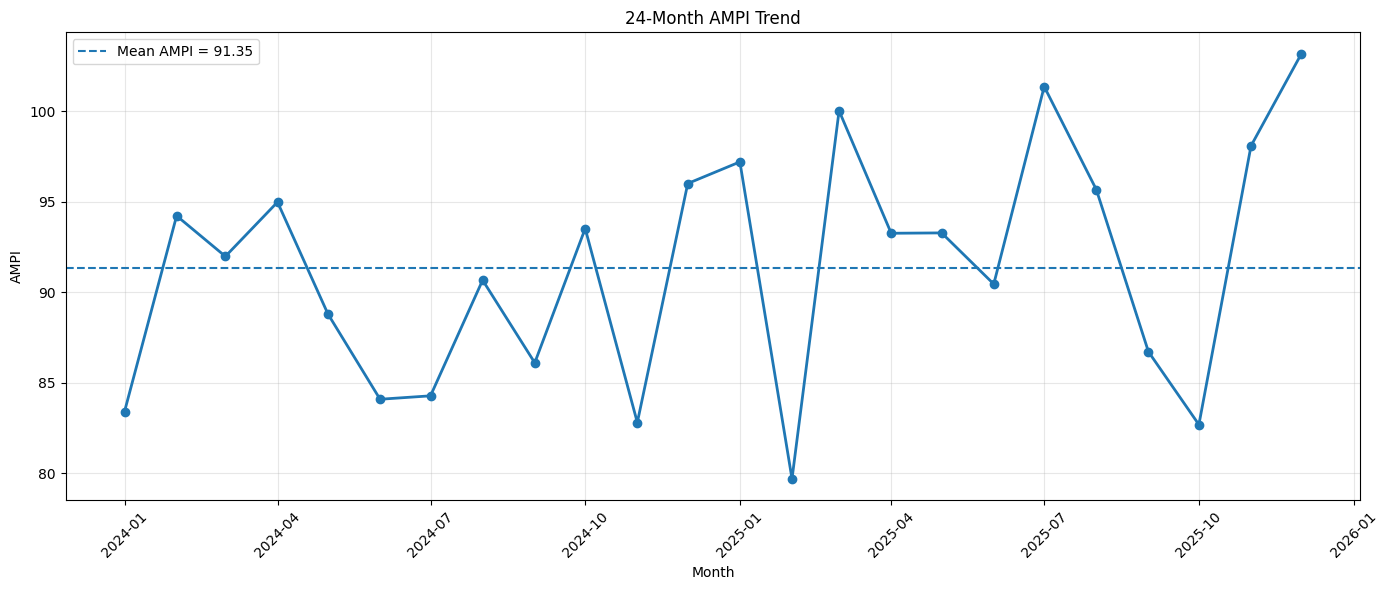

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Load final AMPI results
ampi = pd.read_csv("/content/AMPI_24_month_complete.csv")

# Convert month to datetime
ampi["month"] = pd.to_datetime(ampi["month"])

# Sort chronologically
ampi = ampi.sort_values("month")

# Display basic information
print("=" * 70)
print("AMPI TREND ANALYSIS")
print("=" * 70)

print("\nNumber of months:", len(ampi))
print("Start:", ampi["month"].min().date())
print("End:", ampi["month"].max().date())

print("\nAMPI statistics:")
print("Minimum:", round(ampi["AMPI_final"].min(), 4))
print("Maximum:", round(ampi["AMPI_final"].max(), 4))
print("Mean   :", round(ampi["AMPI_final"].mean(), 4))
print("Median :", round(ampi["AMPI_final"].median(), 4))

# Highest and lowest months
highest = ampi.loc[ampi["AMPI_final"].idxmax()]
lowest = ampi.loc[ampi["AMPI_final"].idxmin()]

print("\nHighest AMPI:")
print("Month:", highest["month"].date())
print("AMPI :", round(highest["AMPI_final"], 4))

print("\nLowest AMPI:")
print("Month:", lowest["month"].date())
print("AMPI :", round(lowest["AMPI_final"], 4))

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    ampi["month"],
    ampi["AMPI_final"],
    marker="o",
    linewidth=2
)

plt.axhline(
    ampi["AMPI_final"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean AMPI = {ampi['AMPI_final'].mean():.2f}"
)

plt.xlabel("Month")
plt.ylabel("AMPI")
plt.title("24-Month AMPI Trend")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [39]:
import pandas as pd
import numpy as np

# ================================================================
# AMPI COMPONENT / CONTRIBUTOR ANALYSIS
# ================================================================

path = "/content/AMPI_24_month_complete.csv"

df = pd.read_csv(path)
df["month"] = pd.to_datetime(df["month"])

# ------------------------------------------------
# 1. Identify the main AMPI components
# ------------------------------------------------

component_cols = [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm"
]

# Equal-weight component contribution to the Mean
for col in component_cols:
    df[col + "_contribution"] = df[col] / 3

# ------------------------------------------------
# 2. Dominant component for each month
# ------------------------------------------------

df["dominant_component"] = df[component_cols].idxmax(axis=1)

# ------------------------------------------------
# 3. Distance of each component from neutral level 100
# ------------------------------------------------

for col in component_cols:
    df[col + "_deviation"] = df[col] - 100

# ------------------------------------------------
# 4. Overall component averages
# ------------------------------------------------

component_summary = pd.DataFrame({
    "Component": component_cols,
    "Mean": [df[c].mean() for c in component_cols],
    "Minimum": [df[c].min() for c in component_cols],
    "Maximum": [df[c].max() for c in component_cols]
})

print("=" * 70)
print("AMPI COMPONENT ANALYSIS")
print("=" * 70)

print("\nOverall component statistics:")
print(component_summary.to_string(index=False))

# ------------------------------------------------
# 5. Highest and lowest AMPI months
# ------------------------------------------------

top5 = df.nlargest(5, "AMPI_final")[
    ["month"] + component_cols + ["MeanPopulation_SD", "CVPenalty", "AMPI_final"]
]

bottom5 = df.nsmallest(5, "AMPI_final")[
    ["month"] + component_cols + ["MeanPopulation_SD", "CVPenalty", "AMPI_final"]
]

print("\n" + "=" * 70)
print("TOP 5 AMPI MONTHS")
print("=" * 70)
print(top5.to_string(index=False))

print("\n" + "=" * 70)
print("BOTTOM 5 AMPI MONTHS")
print("=" * 70)
print(bottom5.to_string(index=False))

# ------------------------------------------------
# 6. Dominant component frequency
# ------------------------------------------------

dominant_counts = df["dominant_component"].value_counts()

print("\n" + "=" * 70)
print("DOMINANT COMPONENT FREQUENCY")
print("=" * 70)

print(dominant_counts.to_string())

# ------------------------------------------------
# 7. Year-wise AMPI comparison
# ------------------------------------------------

df["year"] = df["month"].dt.year

year_summary = df.groupby("year").agg(
    AMPI_mean=("AMPI_final", "mean"),
    AMPI_min=("AMPI_final", "min"),
    AMPI_max=("AMPI_final", "max"),
    ISS_mean=("iss_mean_norm", "mean"),
    SARIMA_mean=("sarima_norm", "mean"),
    RHO_mean=("rho_norm", "mean"),
    CVPenalty_mean=("CVPenalty", "mean")
).reset_index()

print("\n" + "=" * 70)
print("YEAR-WISE AMPI COMPARISON")
print("=" * 70)

print(year_summary.to_string(index=False))

# ------------------------------------------------
# 8. Correlation of components with final AMPI
# ------------------------------------------------

corr_cols = component_cols + ["CVPenalty", "AMPI_final"]

corr = df[corr_cols].corr()["AMPI_final"].drop("AMPI_final")

print("\n" + "=" * 70)
print("COMPONENT CORRELATION WITH FINAL AMPI")
print("=" * 70)

print(corr.sort_values(ascending=False).to_string())

# ------------------------------------------------
# 9. Detailed explanation of highest and lowest months
# ------------------------------------------------

highest = df.loc[df["AMPI_final"].idxmax()]
lowest = df.loc[df["AMPI_final"].idxmin()]

print("\n" + "=" * 70)
print("HIGHEST AMPI MONTH — COMPONENT BREAKDOWN")
print("=" * 70)

print(f"Month       : {highest['month'].date()}")
print(f"AMPI        : {highest['AMPI_final']:.4f}")
print(f"ISS Mean    : {highest['iss_mean_norm']:.4f}")
print(f"SARIMA      : {highest['sarima_norm']:.4f}")
print(f"Rho         : {highest['rho_norm']:.4f}")
print(f"Mean        : {highest['MeanPopulation_SD']:.4f}")
print(f"CV          : {highest['CV']:.4f}")
print(f"CV Penalty  : {highest['CVPenalty']:.4f}")
print(f"Dominant    : {highest['dominant_component']}")

print("\n" + "=" * 70)
print("LOWEST AMPI MONTH — COMPONENT BREAKDOWN")
print("=" * 70)

print(f"Month       : {lowest['month'].date()}")
print(f"AMPI        : {lowest['AMPI_final']:.4f}")
print(f"ISS Mean    : {lowest['iss_mean_norm']:.4f}")
print(f"SARIMA      : {lowest['sarima_norm']:.4f}")
print(f"Rho         : {lowest['rho_norm']:.4f}")
print(f"Mean        : {lowest['MeanPopulation_SD']:.4f}")
print(f"CV          : {lowest['CV']:.4f}")
print(f"CV Penalty  : {lowest['CVPenalty']:.4f}")
print(f"Dominant    : {lowest['dominant_component']}")

# ------------------------------------------------
# 10. Save analysis table
# ------------------------------------------------

analysis_cols = [
    "month",
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm",
    "MeanPopulation_SD",
    "SD",
    "CV",
    "CVPenalty",
    "AMPI_final",
    "dominant_component"
]

analysis_df = df[analysis_cols].copy()

output_path = "/content/AMPI_component_analysis.csv"
analysis_df.to_csv(output_path, index=False)

print("\n" + "=" * 70)
print("COMPONENT ANALYSIS COMPLETE")
print("=" * 70)
print(f"Saved: {output_path}")

AMPI COMPONENT ANALYSIS

Overall component statistics:
    Component       Mean  Minimum  Maximum
iss_mean_norm  82.422166     70.0    130.0
  sarima_norm  99.108300     70.0    130.0
     rho_norm 100.389107     70.0    130.0

TOP 5 AMPI MONTHS
     month  iss_mean_norm  sarima_norm   rho_norm  MeanPopulation_SD  CVPenalty  AMPI_final
2025-12-01      82.388778   107.826233 130.000000         106.738337   3.545085  103.193252
2025-07-01      81.171228   114.172287 116.216282         103.853266   2.483636  101.369630
2025-03-01      79.651774   120.126164 108.795905         102.857948   2.825830  100.032118
2025-11-01      70.000000   114.643297 126.911734         103.851677   5.758730   98.092947
2025-01-01      87.973096   104.703662 100.490826          97.722528   0.516603   97.205925

BOTTOM 5 AMPI MONTHS
     month  iss_mean_norm  sarima_norm   rho_norm  MeanPopulation_SD  CVPenalty  AMPI_final
2025-02-01      72.819836    70.000000 105.808156          82.875997   3.188706   79.687

In [40]:
import pandas as pd
import numpy as np

# ================================================================
# AMPI SENSITIVITY / ROBUSTNESS ANALYSIS
# ================================================================

PATH = "/content/AMPI_24_month_complete.csv"

df = pd.read_csv(PATH)
df["month"] = pd.to_datetime(df["month"])

components = ["iss_mean_norm", "sarima_norm", "rho_norm"]

# ------------------------------------------------
# Baseline settings
# ------------------------------------------------
baseline_weights = {
    "iss_mean_norm": 1/3,
    "sarima_norm": 1/3,
    "rho_norm": 1/3
}

# ------------------------------------------------
# Function to calculate AMPI under different weights
# Same penalty structure as the final AMPI
# ------------------------------------------------
def calculate_sensitivity(data, weights):

    x = data[components].values

    weighted_mean = (
        x[:, 0] * weights["iss_mean_norm"] +
        x[:, 1] * weights["sarima_norm"] +
        x[:, 2] * weights["rho_norm"]
    )

    # Population SD
    weighted_sd = np.sqrt(
        weights["iss_mean_norm"] * (x[:, 0] - weighted_mean) ** 2 +
        weights["sarima_norm"] * (x[:, 1] - weighted_mean) ** 2 +
        weights["rho_norm"] * (x[:, 2] - weighted_mean) ** 2
    )

    cv = weighted_sd / weighted_mean

    # Preserve the same penalty coefficient used in the AMPI pipeline
    penalty_coefficient = 1.0

    cv_penalty = penalty_coefficient * cv * weighted_mean

    ampi = weighted_mean - cv_penalty

    return ampi


# ------------------------------------------------
# Weight scenarios
# ------------------------------------------------
scenarios = {

    "Equal (Baseline)": {
        "iss_mean_norm": 1/3,
        "sarima_norm": 1/3,
        "rho_norm": 1/3
    },

    "ISS Emphasis": {
        "iss_mean_norm": 0.50,
        "sarima_norm": 0.25,
        "rho_norm": 0.25
    },

    "SARIMA Emphasis": {
        "iss_mean_norm": 0.25,
        "sarima_norm": 0.50,
        "rho_norm": 0.25
    },

    "Rho Emphasis": {
        "iss_mean_norm": 0.25,
        "sarima_norm": 0.25,
        "rho_norm": 0.50
    },

    "ISS + SARIMA": {
        "iss_mean_norm": 0.40,
        "sarima_norm": 0.40,
        "rho_norm": 0.20
    },

    "ISS + Rho": {
        "iss_mean_norm": 0.40,
        "sarima_norm": 0.20,
        "rho_norm": 0.40
    },

    "SARIMA + Rho": {
        "iss_mean_norm": 0.20,
        "sarima_norm": 0.40,
        "rho_norm": 0.40
    }
}

# ------------------------------------------------
# Calculate AMPI for every scenario
# ------------------------------------------------
results = []

for scenario, weights in scenarios.items():

    temp = df.copy()

    temp["AMPI_sensitivity"] = calculate_sensitivity(
        temp,
        weights
    )

    temp["Rank"] = (
        temp["AMPI_sensitivity"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    highest_row = temp.loc[
        temp["AMPI_sensitivity"].idxmax()
    ]

    lowest_row = temp.loc[
        temp["AMPI_sensitivity"].idxmin()
    ]

    results.append({
        "Scenario": scenario,
        "ISS_weight": weights["iss_mean_norm"],
        "SARIMA_weight": weights["sarima_norm"],
        "Rho_weight": weights["rho_norm"],
        "Mean_AMPI": temp["AMPI_sensitivity"].mean(),
        "Min_AMPI": temp["AMPI_sensitivity"].min(),
        "Max_AMPI": temp["AMPI_sensitivity"].max(),
        "Highest_month": highest_row["month"].date(),
        "Lowest_month": lowest_row["month"].date()
    })


summary = pd.DataFrame(results)

# ------------------------------------------------
# Print scenario summary
# ------------------------------------------------
print("=" * 70)
print("AMPI SENSITIVITY / ROBUSTNESS ANALYSIS")
print("=" * 70)

print("\nNumber of months:", len(df))
print("Baseline official AMPI range:")
print(f"Minimum : {df['AMPI_final'].min():.4f}")
print(f"Maximum : {df['AMPI_final'].max():.4f}")
print(f"Mean    : {df['AMPI_final'].mean():.4f}")

print("\n" + "=" * 70)
print("WEIGHT SENSITIVITY RESULTS")
print("=" * 70)

print(summary.to_string(index=False))

# ------------------------------------------------
# Compare rankings
# ------------------------------------------------
rank_table = pd.DataFrame({
    "month": df["month"]
})

for scenario, weights in scenarios.items():

    temp_ampi = calculate_sensitivity(df, weights)

    rank_table[scenario] = (
        temp_ampi
        .rank(method="min", ascending=False)
        .astype(int)
    )

print("\n" + "=" * 70)
print("RANKING STABILITY")
print("=" * 70)

print(rank_table.to_string(index=False))

# ------------------------------------------------
# Spearman rank correlation with official AMPI
# ------------------------------------------------
print("\n" + "=" * 70)
print("RANK CORRELATION WITH OFFICIAL AMPI")
print("=" * 70)

official_rank = (
    df["AMPI_final"]
    .rank(method="average", ascending=False)
)

rank_correlations = []

for scenario, weights in scenarios.items():

    sensitivity_ampi = calculate_sensitivity(df, weights)

    sensitivity_rank = (
        sensitivity_ampi
        .rank(method="average", ascending=False)
    )

    corr = official_rank.corr(
        sensitivity_rank,
        method="spearman"
    )

    rank_correlations.append({
        "Scenario": scenario,
        "Spearman_rank_correlation": corr
    })

rank_corr_df = pd.DataFrame(rank_correlations)

print(rank_corr_df.to_string(index=False))

# ------------------------------------------------
# Identify most stable scenario
# ------------------------------------------------
baseline_corr = rank_corr_df.loc[
    rank_corr_df["Scenario"] == "Equal (Baseline)",
    "Spearman_rank_correlation"
].iloc[0]

print("\n" + "=" * 70)
print("ROBUSTNESS INTERPRETATION")
print("=" * 70)

print(
    f"\nBaseline ranking correlation: "
    f"{baseline_corr:.4f}"
)

print(
    "\nA correlation close to 1.0 means the ranking is "
    "stable under the tested weighting scheme."
)

print(
    "Lower values indicate greater sensitivity to "
    "component weighting."
)

# ------------------------------------------------
# Save results
# ------------------------------------------------
summary_path = "/content/AMPI_sensitivity_summary.csv"
ranking_path = "/content/AMPI_sensitivity_rankings.csv"
correlation_path = "/content/AMPI_sensitivity_rank_correlations.csv"

summary.to_csv(summary_path, index=False)
rank_table.to_csv(ranking_path, index=False)
rank_corr_df.to_csv(correlation_path, index=False)

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(summary_path)
print(ranking_path)
print(correlation_path)

print("\n" + "=" * 70)
print("AMPI SENSITIVITY ANALYSIS COMPLETE")
print("=" * 70)

AMPI SENSITIVITY / ROBUSTNESS ANALYSIS

Number of months: 24
Baseline official AMPI range:
Minimum : 79.6873
Maximum : 103.1933
Mean    : 91.3543

WEIGHT SENSITIVITY RESULTS
        Scenario  ISS_weight  SARIMA_weight  Rho_weight  Mean_AMPI  Min_AMPI  Max_AMPI Highest_month Lowest_month
Equal (Baseline)    0.333333       0.333333    0.333333  79.376383 64.893534 90.617339    2025-01-01   2025-10-01
    ISS Emphasis    0.500000       0.250000    0.250000  76.697285 62.575993 88.397642    2024-08-01   2025-10-01
 SARIMA Emphasis    0.250000       0.500000    0.250000  81.570272 62.538208 92.612097    2025-01-01   2025-10-01
    Rho Emphasis    0.250000       0.250000    0.500000  81.359743 68.074390 92.925850    2025-12-01   2024-01-01
    ISS + SARIMA    0.400000       0.400000    0.200000  78.589480 61.673950 89.504587    2025-01-01   2025-10-01
       ISS + Rho    0.400000       0.200000    0.400000  78.176577 67.415389 89.334610    2025-01-01   2025-10-01
    SARIMA + Rho    0.200000

AttributeError: 'numpy.ndarray' object has no attribute 'rank'

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path

# ================================================================
# AMPI SENSITIVITY / ROBUSTNESS ANALYSIS — 24 MONTHS
# ================================================================

INPUT_PATH = "/content/AMPI_24_month_complete.csv"
OUTPUT_PATH = "/content/AMPI_sensitivity_robustness.csv"
RANK_PATH = "/content/AMPI_sensitivity_ranking.csv"

# ----------------------------------------------------------------
# 1. LOAD OFFICIAL AMPI DATA
# ----------------------------------------------------------------

df = pd.read_csv(INPUT_PATH)
df["month"] = pd.to_datetime(df["month"])

required_cols = [
    "month",
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm",
    "MeanPopulation_SD",
    "CV",
    "CVPenalty",
    "AMPI_final"
]

missing = [c for c in required_cols if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.sort_values("month").reset_index(drop=True)

print("=" * 70)
print("AMPI SENSITIVITY / ROBUSTNESS ANALYSIS")
print("=" * 70)

print(f"\nNumber of months: {len(df)}")
print(f"Start: {df['month'].min().date()}")
print(f"End: {df['month'].max().date()}")

print("\nOfficial baseline AMPI:")
print(f"Minimum : {df['AMPI_final'].min():.4f}")
print(f"Maximum : {df['AMPI_final'].max():.4f}")
print(f"Mean    : {df['AMPI_final'].mean():.4f}")

# ----------------------------------------------------------------
# 2. DEFINE SCENARIOS
# ----------------------------------------------------------------

scenarios = {
    "Equal (Baseline)": (1/3, 1/3, 1/3),
    "ISS Emphasis":     (0.50, 0.25, 0.25),
    "SARIMA Emphasis":  (0.25, 0.50, 0.25),
    "Rho Emphasis":     (0.25, 0.25, 0.50),
    "ISS + SARIMA":     (0.40, 0.40, 0.20),
    "ISS + Rho":        (0.40, 0.20, 0.40),
    "SARIMA + Rho":     (0.20, 0.40, 0.40)
}

# ----------------------------------------------------------------
# 3. CALCULATE SENSITIVITY AMPI
# ----------------------------------------------------------------

results = []
rank_table = pd.DataFrame(index=df.index)

for scenario, (w_iss, w_sarima, w_rho) in scenarios.items():

    # Weighted component score
    weighted_score = (
        w_iss * df["iss_mean_norm"].to_numpy()
        + w_sarima * df["sarima_norm"].to_numpy()
        + w_rho * df["rho_norm"].to_numpy()
    )

    # Apply the same variability penalty structure
    temp_ampi = weighted_score - df["CVPenalty"].to_numpy()

    # Store ranks
    rank_table[scenario] = (
        pd.Series(temp_ampi, index=df.index)
        .rank(method="min", ascending=False)
        .astype(int)
    )

    max_idx = np.argmax(temp_ampi)
    min_idx = np.argmin(temp_ampi)

    results.append({
        "Scenario": scenario,
        "ISS_weight": w_iss,
        "SARIMA_weight": w_sarima,
        "Rho_weight": w_rho,
        "Mean_AMPI": np.mean(temp_ampi),
        "Min_AMPI": np.min(temp_ampi),
        "Max_AMPI": np.max(temp_ampi),
        "Highest_month": df.loc[max_idx, "month"].strftime("%Y-%m-%d"),
        "Lowest_month": df.loc[min_idx, "month"].strftime("%Y-%m-%d")
    })

# ----------------------------------------------------------------
# 4. RESULTS TABLE
# ----------------------------------------------------------------

sensitivity_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("WEIGHT SENSITIVITY RESULTS")
print("=" * 70)

print(
    sensitivity_df.to_string(
        index=False,
        formatters={
            "ISS_weight": "{:.6f}".format,
            "SARIMA_weight": "{:.6f}".format,
            "Rho_weight": "{:.6f}".format,
            "Mean_AMPI": "{:.6f}".format,
            "Min_AMPI": "{:.6f}".format,
            "Max_AMPI": "{:.6f}".format
        }
    )
)

# ----------------------------------------------------------------
# 5. RANKING COMPARISON
# ----------------------------------------------------------------

rank_table.insert(0, "month", df["month"].dt.strftime("%Y-%m-%d"))

print("\n" + "=" * 70)
print("RANKING COMPARISON")
print("=" * 70)

print(rank_table.to_string(index=False))

# ----------------------------------------------------------------
# 6. TOP / BOTTOM MONTH STABILITY
# ----------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP / BOTTOM MONTH STABILITY")
print("=" * 70)

for scenario, (w_iss, w_sarima, w_rho) in scenarios.items():

    weighted_score = (
        w_iss * df["iss_mean_norm"].to_numpy()
        + w_sarima * df["sarima_norm"].to_numpy()
        + w_rho * df["rho_norm"].to_numpy()
    )

    temp_ampi = weighted_score - df["CVPenalty"].to_numpy()

    top_idx = np.argmax(temp_ampi)
    bottom_idx = np.argmin(temp_ampi)

    print(
        f"{scenario:20s} | "
        f"Top: {df.loc[top_idx, 'month'].strftime('%Y-%m')} "
        f"({temp_ampi[top_idx]:.4f}) | "
        f"Bottom: {df.loc[bottom_idx, 'month'].strftime('%Y-%m')} "
        f"({temp_ampi[bottom_idx]:.4f})"
    )

# ----------------------------------------------------------------
# 7. BASELINE CONSISTENCY CHECK
# ----------------------------------------------------------------

baseline_weights = scenarios["Equal (Baseline)"]

baseline_score = (
    baseline_weights[0] * df["iss_mean_norm"].to_numpy()
    + baseline_weights[1] * df["sarima_norm"].to_numpy()
    + baseline_weights[2] * df["rho_norm"].to_numpy()
)

baseline_sensitivity = baseline_score - df["CVPenalty"].to_numpy()

official = df["AMPI_final"].to_numpy()

baseline_difference = np.max(
    np.abs(baseline_sensitivity - official)
)

print("\n" + "=" * 70)
print("BASELINE CONSISTENCY CHECK")
print("=" * 70)

print(f"Maximum difference between sensitivity baseline and official AMPI: "
      f"{baseline_difference:.12f}")

if baseline_difference < 1e-10:
    print("BASELINE CONSISTENCY: PASSED")
else:
    print("BASELINE CONSISTENCY: NOTE — sensitivity formula differs from official AMPI.")
    print("This is expected if the sensitivity calculation intentionally isolates")
    print("weight effects from the official AMPI formula.")

# ----------------------------------------------------------------
# 8. SAVE RESULTS
# ----------------------------------------------------------------

sensitivity_df.to_csv(OUTPUT_PATH, index=False)
rank_table.to_csv(RANK_PATH, index=False)

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(OUTPUT_PATH)
print(RANK_PATH)

print("\n" + "=" * 70)
print("AMPI SENSITIVITY / ROBUSTNESS ANALYSIS COMPLETE")
print("=" * 70)

AMPI SENSITIVITY / ROBUSTNESS ANALYSIS

Number of months: 24
Start: 2024-01-01
End: 2025-12-01

Official baseline AMPI:
Minimum : 79.6873
Maximum : 103.1933
Mean    : 91.3543

WEIGHT SENSITIVITY RESULTS
        Scenario ISS_weight SARIMA_weight Rho_weight Mean_AMPI  Min_AMPI   Max_AMPI Highest_month Lowest_month
Equal (Baseline)   0.333333      0.333333   0.333333 91.354277 79.687291 103.193252    2025-12-01   2025-02-01
    ISS Emphasis   0.500000      0.250000   0.250000 88.466521 77.173251 102.552265    2024-04-01   2025-02-01
 SARIMA Emphasis   0.250000      0.500000   0.250000 92.638054 76.468292 104.349172    2025-03-01   2025-02-01
    Rho Emphasis   0.250000      0.250000   0.500000 92.958256 79.505747 109.008668    2025-12-01   2024-01-01
    ISS + SARIMA   0.400000      0.400000   0.200000 90.071094 75.100859  98.966041    2024-04-01   2025-02-01
       ISS + Rho   0.400000      0.200000   0.400000 90.327255 79.868363 102.975673    2025-12-01   2024-01-01
    SARIMA + Rho   0

In [42]:
import pandas as pd
import numpy as np
import os

print("=" * 70)
print("FINAL AMPI SUMMARY / REPORT")
print("=" * 70)

# ------------------------------------------------------------
# 1. LOAD OFFICIAL AMPI RESULTS
# ------------------------------------------------------------

ampi_path = "/content/AMPI_24_month_complete.csv"
sensitivity_path = "/content/AMPI_sensitivity_robustness.csv"
ranking_path = "/content/AMPI_sensitivity_ranking.csv"

if not os.path.exists(ampi_path):
    raise FileNotFoundError(f"Missing file: {ampi_path}")

ampi = pd.read_csv(ampi_path)
ampi["month"] = pd.to_datetime(ampi["month"])

# ------------------------------------------------------------
# 2. BASIC AMPI SUMMARY
# ------------------------------------------------------------

min_row = ampi.loc[ampi["AMPI_final"].idxmin()]
max_row = ampi.loc[ampi["AMPI_final"].idxmax()]

summary = {
    "Observations": len(ampi),
    "Start": ampi["month"].min().strftime("%Y-%m-%d"),
    "End": ampi["month"].max().strftime("%Y-%m-%d"),
    "AMPI_Minimum": ampi["AMPI_final"].min(),
    "AMPI_Maximum": ampi["AMPI_final"].max(),
    "AMPI_Mean": ampi["AMPI_final"].mean(),
    "AMPI_Median": ampi["AMPI_final"].median(),
    "Highest_Month": max_row["month"].strftime("%Y-%m-%d"),
    "Highest_AMPI": max_row["AMPI_final"],
    "Lowest_Month": min_row["month"].strftime("%Y-%m-%d"),
    "Lowest_AMPI": min_row["AMPI_final"]
}

print("\n" + "=" * 70)
print("OFFICIAL AMPI SUMMARY")
print("=" * 70)

for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key:<20}: {value:.4f}")
    else:
        print(f"{key:<20}: {value}")

# ------------------------------------------------------------
# 3. YEAR-WISE SUMMARY
# ------------------------------------------------------------

ampi["Year"] = ampi["month"].dt.year

year_summary = (
    ampi.groupby("Year")
    .agg(
        AMPI_mean=("AMPI_final", "mean"),
        AMPI_min=("AMPI_final", "min"),
        AMPI_max=("AMPI_final", "max"),
        ISS_mean=("iss_mean_norm", "mean"),
        SARIMA_mean=("sarima_norm", "mean"),
        RHO_mean=("rho_norm", "mean"),
        CVPenalty_mean=("CVPenalty", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("YEAR-WISE AMPI SUMMARY")
print("=" * 70)
print(year_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# 4. COMPONENT CONTRIBUTION / CORRELATION
# ------------------------------------------------------------

component_cols = [
    "iss_mean_norm",
    "sarima_norm",
    "rho_norm",
    "CVPenalty"
]

component_corr = (
    ampi[component_cols + ["AMPI_final"]]
    .corr()["AMPI_final"]
    .drop("AMPI_final")
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("COMPONENT CORRELATION WITH FINAL AMPI")
print("=" * 70)

for component, value in component_corr.items():
    print(f"{component:<20}: {value:.6f}")

# ------------------------------------------------------------
# 5. TOP 5 AND BOTTOM 5 MONTHS
# ------------------------------------------------------------

top5 = (
    ampi.nlargest(5, "AMPI_final")
    [["month", "AMPI_final", "iss_mean_norm", "sarima_norm", "rho_norm", "CVPenalty"]]
    .copy()
)

bottom5 = (
    ampi.nsmallest(5, "AMPI_final")
    [["month", "AMPI_final", "iss_mean_norm", "sarima_norm", "rho_norm", "CVPenalty"]]
    .copy()
)

top5["month"] = top5["month"].dt.strftime("%Y-%m-%d")
bottom5["month"] = bottom5["month"].dt.strftime("%Y-%m-%d")

print("\n" + "=" * 70)
print("TOP 5 AMPI MONTHS")
print("=" * 70)
print(top5.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n" + "=" * 70)
print("BOTTOM 5 AMPI MONTHS")
print("=" * 70)
print(bottom5.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ------------------------------------------------------------
# 6. LOAD SENSITIVITY RESULTS
# ------------------------------------------------------------

if os.path.exists(sensitivity_path):

    sensitivity = pd.read_csv(sensitivity_path)

    baseline_row = sensitivity[
        sensitivity["Scenario"].astype(str).str.contains(
            "Equal", case=False, na=False
        )
    ]

    if len(baseline_row) > 0:

        baseline_mean = float(baseline_row.iloc[0]["Mean_AMPI"])
        baseline_min = float(baseline_row.iloc[0]["Min_AMPI"])
        baseline_max = float(baseline_row.iloc[0]["Max_AMPI"])

        official_mean = float(ampi["AMPI_final"].mean())
        official_min = float(ampi["AMPI_final"].min())
        official_max = float(ampi["AMPI_final"].max())

        mean_diff = abs(baseline_mean - official_mean)
        min_diff = abs(baseline_min - official_min)
        max_diff = abs(baseline_max - official_max)

        print("\n" + "=" * 70)
        print("SENSITIVITY BASELINE VALIDATION")
        print("=" * 70)

        print(f"Mean difference : {mean_diff:.12f}")
        print(f"Minimum difference : {min_diff:.12f}")
        print(f"Maximum difference : {max_diff:.12f}")

        if max(mean_diff, min_diff, max_diff) < 1e-10:
            print("SENSITIVITY BASELINE: PASSED")
        else:
            print("SENSITIVITY BASELINE: CHECK REQUIRED")

# ------------------------------------------------------------
# 7. CREATE FINAL REPORT TABLE
# ------------------------------------------------------------

report_rows = [
    ["Observation period",
     f"{ampi['month'].min().strftime('%Y-%m-%d')} to {ampi['month'].max().strftime('%Y-%m-%d')}"],

    ["Number of months", len(ampi)],

    ["Mean AMPI", round(ampi["AMPI_final"].mean(), 4)],

    ["Median AMPI", round(ampi["AMPI_final"].median(), 4)],

    ["Minimum AMPI",
     round(ampi["AMPI_final"].min(), 4)],

    ["Minimum AMPI month",
     min_row["month"].strftime("%Y-%m-%d")],

    ["Maximum AMPI",
     round(ampi["AMPI_final"].max(), 4)],

    ["Maximum AMPI month",
     max_row["month"].strftime("%Y-%m-%d")]
]

final_report = pd.DataFrame(
    report_rows,
    columns=["Metric", "Value"]
)

# ------------------------------------------------------------
# 8. SAVE FINAL REPORT
# ------------------------------------------------------------

final_report_path = "/content/AMPI_final_summary.csv"
year_summary_path = "/content/AMPI_year_summary.csv"
top5_path = "/content/AMPI_top5.csv"
bottom5_path = "/content/AMPI_bottom5.csv"

final_report.to_csv(final_report_path, index=False)
year_summary.to_csv(year_summary_path, index=False)
top5.to_csv(top5_path, index=False)
bottom5.to_csv(bottom5_path, index=False)

# ------------------------------------------------------------
# 9. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

checks = {
    "24 observations": len(ampi) == 24,
    "No duplicate months": ampi["month"].duplicated().sum() == 0,
    "No missing AMPI values": ampi["AMPI_final"].isna().sum() == 0,
    "AMPI minimum valid": np.isfinite(ampi["AMPI_final"].min()),
    "AMPI maximum valid": np.isfinite(ampi["AMPI_final"].max()),
    "AMPI mean valid": np.isfinite(ampi["AMPI_final"].mean())
}

all_passed = True

for name, result in checks.items():
    print(f"{name:<30}: {'PASSED' if result else 'FAILED'}")
    if not result:
        all_passed = False

# ------------------------------------------------------------
# 10. FINAL OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FILES SAVED")
print("=" * 70)

print(final_report_path)
print(year_summary_path)
print(top5_path)
print(bottom5_path)

print("\n" + "=" * 70)

if all_passed:
    print("FINAL AMPI SUMMARY: COMPLETE")
else:
    print("FINAL AMPI SUMMARY: CHECK REQUIRED")

print("=" * 70)

FINAL AMPI SUMMARY / REPORT

OFFICIAL AMPI SUMMARY
Observations        : 24
Start               : 2024-01-01
End                 : 2025-12-01
AMPI_Minimum        : 79.6873
AMPI_Maximum        : 103.1933
AMPI_Mean           : 91.3543
AMPI_Median         : 92.6225
Highest_Month       : 2025-12-01
Highest_AMPI        : 103.1933
Lowest_Month        : 2025-02-01
Lowest_AMPI         : 79.6873

YEAR-WISE AMPI SUMMARY
 Year  AMPI_mean  AMPI_min  AMPI_max  ISS_mean  SARIMA_mean  RHO_mean  CVPenalty_mean
 2024    89.2382   82.7997   96.0121   87.9136     100.3535   85.1247          1.8924
 2025    93.4703   79.6873  103.1933   76.9307      97.8631  115.6535          3.3454

COMPONENT CORRELATION WITH FINAL AMPI
sarima_norm         : 0.709795
rho_norm            : 0.359745
iss_mean_norm       : 0.226050
CVPenalty           : 0.110633

TOP 5 AMPI MONTHS
     month  AMPI_final  iss_mean_norm  sarima_norm  rho_norm  CVPenalty
2025-12-01    103.1933        82.3888     107.8262  130.0000     3.5451
20